In [1]:
import os
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo


/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
adata_age_cd8= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.h5ad")

In [18]:
adata_age_cd8

AnnData object with n_obs × n_vars = 265568 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age i

In [19]:
adata_age_cd8.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_cd8.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD8 naive/Tcm          175694
CD8 Tem                 50185
CD8 GZMK+ naive/Tcm     39689
Name: count, dtype: int64

In [20]:
adata_age_cd8.obs["pica_id"].unique()
adata_age_cd8.obs["pica_id"].value_counts()

pica_id
PICA0040    3781
PICA0141    3695
PICA0022    3481
PICA0140    3303
PICA0173    3213
            ... 
PICA0010     585
PICA0005     484
PICA0003     441
PICA0002     396
PICA0004     393
Name: count, Length: 128, dtype: int64

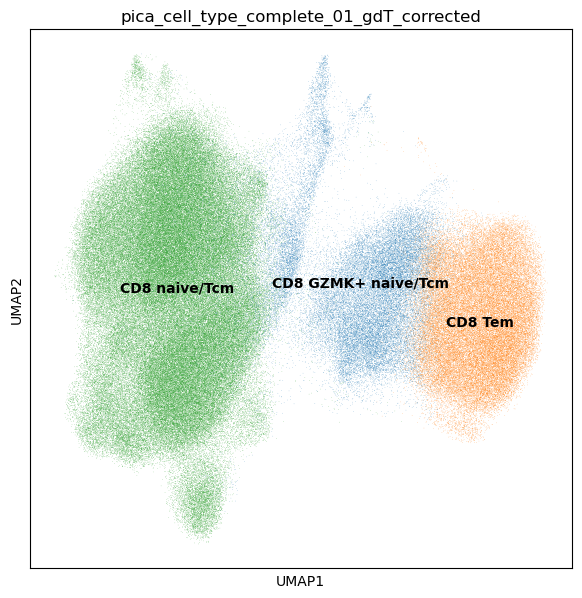

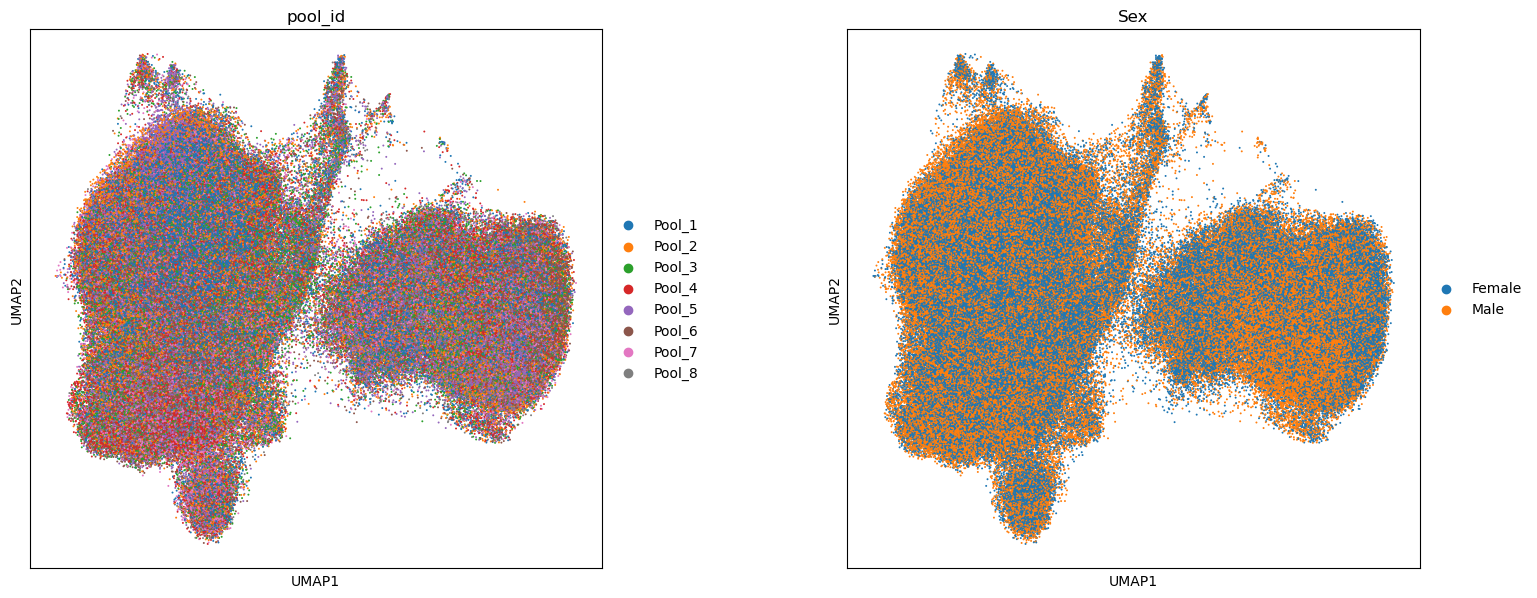

In [21]:
sc.pl.umap(adata_age_cd8, color=["pica_cell_type_complete_01_gdT_corrected"], legend_loc="on data")
sc.pl.umap(adata_age_cd8, color=["pool_id", "Sex"], wspace=0.3, size=8)

### Prepare for Milo analysis

In [22]:
adata_age_cd8.obs['Batch'] = adata_age_cd8.obs['sequencing_batch'].map(
        {
            '20240530_WGS_20240530_sc_PICA0001-PICA0007': "Batch01",
            '20240918_WGS_20240924_sc_PICA0008-PICA0032': "Batch02",
            '20241106_WGS_20241106_sc_PICA0033-PICA0069': "Batch03",
            '20250114_WGS_20241218_sc_PICA0071-PICA0097': "Batch04",
            '20250324_WGS_20250324_sc_PICA0098-PICA0118': "Batch05",
            '20250612_WGS_20250612_sc_PICA0119-PICA0146': "Batch06",
            '20250814_WGS_20250814_sc_PICA0147-PICA0173': "Batch07"
        }
    )

adata_age_cd8.obs["Age_group"] = pd.Categorical(
        adata_age_cd8.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )

adata_age_cd8.obs = adata_age_cd8.obs.rename(columns={
    "Age (years)": "Age_years"
})

adata_age_cd8.obs["Batch"] = adata_age_cd8.obs["Batch"].astype("category")
adata_age_cd8.obs["Age_years"] = adata_age_cd8.obs["Age_years"].astype("float")
adata_age_cd8.obs["Sex"] = adata_age_cd8.obs["Sex"].astype("category")
adata_age_cd8.obs["Age"] = adata_age_cd8.obs["Age"].astype("int")

In [23]:
adata_age_cd8.obs["Sex"].value_counts()


Sex
Male      152037
Female    113531
Name: count, dtype: int64

In [24]:
adata_age_cd8.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     1489
0.07      585
0.14      663
0.35     2293
0.48     1267
         ... 
16.16    1848
16.20    2413
16.29    2501
16.78    1559
17.03    3096
Name: count, Length: 122, dtype: int64

In [25]:
adata_age_cd8.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      58370
4–6      64945
7–10     43721
11–14    72625
15–18    25907
Name: count, dtype: int64

In [26]:
adata_age_cd8.obs["Age"].value_counts().sort_index()

Age
0     15038
1      9466
2     15862
3     18004
4     27429
5     14860
6     22656
7     16540
8     12849
9      7687
10     6645
11    20207
12    14386
13    14981
14    23051
15    12466
16    10345
17     3096
Name: count, dtype: int64

In [27]:
adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/21970055/ipykernel_187881/2309978465.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")


,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [28]:
adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/21970055/ipykernel_187881/587457404.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")


,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [29]:
milo = pt.tl.Milo()
mdata_cd8 = milo.load(adata_age_cd8)

In [30]:
mdata_cd8

MuData object with n_obs × n_vars = 265568 × 38606
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	0 x 0

In [31]:
# Build KNN graph
sc.pp.neighbors(mdata_cd8["rna"], use_rep="X_scVI", n_neighbors=150)

In [32]:
# Build neighbourhood graph
milo.make_nhoods(mdata_cd8["rna"], prop=0.1)

In [33]:
mdata_cd8["rna"].obsm["nhoods"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6755188 stored elements and shape (265568, 13739)>

In [34]:
mdata_cd8["rna"][mdata_cd8["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAATCACTCAGCGCAT,1,3.265390
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAATGTCTCAGGACTC,1,3.257657
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACATAACAGTCCATG,1,3.009837
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACCTTACAATACGGA,1,3.541760
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACGGGCAGGTACGTC,1,3.219984
...,...,...
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GCCTTTCCACATGTCG,1,3.201525
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GCGCAATTCACTTCCG,1,3.723792
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GGAACTTGTGGAATGA,1,3.386278
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GGTTAATTCATGTGGC,1,3.204317


Text(0, 0.5, '# nhoods')

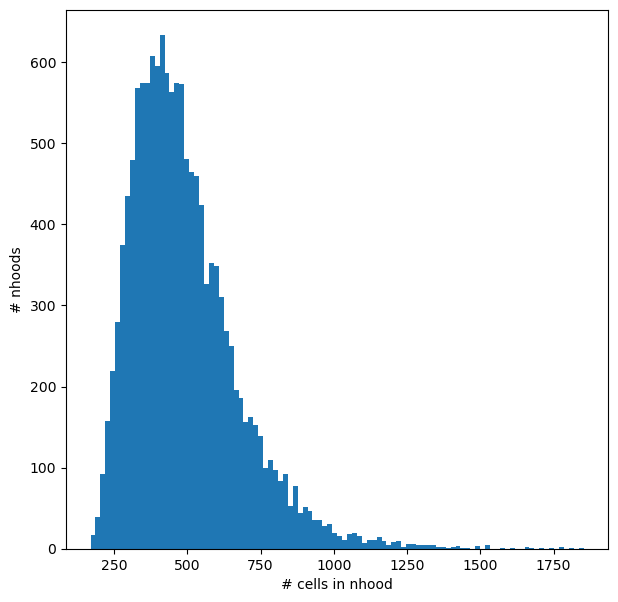

In [35]:
nhood_size = np.array(mdata_cd8["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

In [36]:
# count cells in neighbourhood
mdata_cd8= milo.count_nhoods(mdata_cd8, sample_col="pica_id") 

In [37]:
mdata_cd8

MuData object with n_obs × n_vars = 265568 × 38606
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 13739
      var:	'index_cell', 'kth_distance'
      uns:	'sample_

In [38]:
mdata_cd8["milo"]

AnnData object with n_obs × n_vars = 128 × 13739
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [73]:
donor_meta_cd8 = (
    adata_age_cd8.obs[["pica_id", "Age_years","Age", "Sex", "Batch","Age_group"]]
    .drop_duplicates("pica_id")
    .set_index("pica_id")
)
donor_meta_cd8 = donor_meta_cd8.loc[mdata_cd8["milo"].obs_names]

In [74]:
mdata_cd8["milo"].obs["Age_years"] = donor_meta_cd8["Age_years"].values
mdata_cd8["milo"].obs["Sex"] = donor_meta_cd8["Sex"].values
mdata_cd8["milo"].obs["Batch"] = donor_meta_cd8["Batch"].values
mdata_cd8["milo"].obs["Age"] = donor_meta_cd8["Age"].values
mdata_cd8["milo"].obs["Age_group"] = donor_meta_cd8["Age_group"].values

In [75]:
"""
mdata_cd8["milo"].obs["Age_group"] = pd.Categorical(
    mdata_cd8["milo"].obs["Age_group"],
    categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
    ordered=True
)
"""
mdata_cd8["milo"].obs["Sex"] = mdata_cd8["milo"].obs["Sex"].astype("category")
mdata_cd8["milo"].obs["Age_years"] = mdata_cd8["milo"].obs["Age_years"].astype("float")
mdata_cd8["milo"].obs["Batch"] = mdata_cd8["milo"].obs["Batch"].astype("category")
mdata_cd8["milo"].obs["Age"] = mdata_cd8["milo"].obs["Age"].astype("int")
mdata_cd8["milo"].obs["Age_group"] = mdata_cd8["milo"].obs["Age_group"].astype("category")

In [76]:
donor_meta_cd8

,Age_years,Age,Sex,Batch,Age_group
PICA0001,2.09,2,Male,Batch01,0–3
PICA0002,15.09,15,Male,Batch01,15–18
PICA0003,0.83,0,Male,Batch01,0–3
PICA0004,1.46,1,Male,Batch01,0–3
PICA0005,9.30,9,Male,Batch01,7–10
...,...,...,...,...,...
PICA0164,2.15,2,Male,Batch07,0–3
PICA0166,0.62,0,Male,Batch07,0–3
PICA0168,16.20,16,Male,Batch07,15–18
PICA0169,2.72,2,Male,Batch07,0–3


In [42]:
mdata_cd8["milo"].obs["Age_years"].value_counts().sort_index()

Age_years
0.05     1
0.07     1
0.14     1
0.35     1
0.48     1
        ..
16.16    1
16.20    1
16.29    1
16.78    1
17.03    1
Name: count, Length: 122, dtype: int64

In [43]:
mdata_cd8["milo"].obs["Sex"].value_counts().sort_index()

Sex
Female    53
Male      75
Name: count, dtype: int64

In [44]:
mdata_cd8["milo"].obs["Age_group"].value_counts().sort_index()

Age_group
0–3      31
4–6      29
7–10     21
11–14    34
15–18    13
Name: count, dtype: int64

In [30]:
mdata_cd8

MuData object with n_obs × n_vars = 265568 × 38606
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 13739
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'


### DA testing with GLM

In [31]:
mdata_cd8

MuData object with n_obs × n_vars = 265568 × 38606
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 13739
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'


In [32]:
milo.da_nhoods(
    mdata_cd8,
    design="~ Age_years * Sex + Batch",   # Age_group last = main effect of interest
    solver="pydeseq2"                  # use "edger" only if you set up rpy2+edgeR
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(


Fitting dispersions...
... done in 11.24 seconds.

Fitting MAP dispersions...
... done in 2.85 seconds.

Fitting dispersions...
... done in 3.33 seconds.

Fitting MAP dispersions...
... done in 3.11 seconds.

/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Fitting dispersions...
... done in 11.12 seconds.

Fitting MAP dispersions...
... done in 2.86 seconds.

Fitting dispersions...
... done in 2.89 seconds.

Fitting MAP dispersions...
... done in 2.86 seconds.

Fitting dispersions...
... done in 3.12 seconds.

Fitting MAP dispersions...
... done in 2.90 seconds.

Fitting dispersions...
... done in 2.92 seconds.

Fitting MAP dispersions...
... done in 2.83 seconds.

Fitting dispersions...
... done in 2.88 seconds.

Fitting MAP dispersions...
... done in 2.89 seconds

Log2 fold change & Wald test p-value: Batch Batch07 vs Batch01
       baseMean  log2FoldChange     lfcSE      stat        pvalue      padj
0      3.695683       -1.300423  0.785035 -1.656516  9.761732e-02  0.430575
1      3.243048       -2.686069  0.974174 -2.757279  5.828462e-03  0.065974
2      7.897237       -1.225222  0.701581 -1.746371  8.074644e-02  0.391500
3      1.929724        0.541095  1.079212  0.501380  6.161035e-01       NaN
4      3.789357       -2.413162  0.873269 -2.763366  5.720864e-03  0.065067
...         ...             ...       ...       ...           ...       ...
13734  4.077080       -0.958224  0.868987 -1.102692  2.701611e-01  0.631973
13735  3.581736       -1.949850  1.177464 -1.655975  9.772686e-02  0.430627
13736  4.494113       -4.774948  0.893293 -5.345331  9.025201e-08  0.000020
13737  3.109771       -1.293809  0.699944 -1.848446  6.453792e-02  0.343951
13738  4.271211       -3.305535  0.703560 -4.698296  2.623405e-06  0.000209

[13739 rows x 6 columns]

... done in 1.65 seconds.



In [77]:
mdata_cd8["milo"].obs["pica_id"] = mdata_cd8["milo"].obs.index

In [78]:
mdata_cd8["milo"].obs

,Age_years,Batch,Sex,pica_id,Age,Age_group
PICA0001,2.09,Batch01,Male,PICA0001,2,0–3
PICA0002,15.09,Batch01,Male,PICA0002,15,15–18
PICA0003,0.83,Batch01,Male,PICA0003,0,0–3
PICA0004,1.46,Batch01,Male,PICA0004,1,0–3
PICA0005,9.30,Batch01,Male,PICA0005,9,7–10
...,...,...,...,...,...,...
PICA0164,2.15,Batch07,Male,PICA0164,2,0–3
PICA0166,0.62,Batch07,Male,PICA0166,0,0–3
PICA0168,16.20,Batch07,Male,PICA0168,16,15–18
PICA0169,2.72,Batch07,Male,PICA0169,2,0–3


In [34]:
mdata_cd8["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.265390,3.695683,-1.300423,9.761732e-02,0.430575,0.470210
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.257657,3.243048,-2.686069,5.828462e-03,0.065974,0.073724
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.009837,7.897237,-1.225222,8.074644e-02,0.391500,0.428021
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.541760,1.929724,0.541095,6.161035e-01,NaN,0.864849
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.219984,3.789357,-2.413162,5.720864e-03,0.065067,0.072778
...,...,...,...,...,...,...,...
13734,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.201525,4.077080,-0.958224,2.701611e-01,0.631973,0.673203
13735,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.723792,3.581736,-1.949850,9.772686e-02,0.430627,0.470210
13736,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.386278,4.494113,-4.774948,9.025201e-08,0.000020,0.000022
13737,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.204317,3.109771,-1.293809,6.453792e-02,0.343951,0.377802


In [35]:
mdata_cd8.write_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_nhood.h5mu")

In [72]:
mdata_cd8=mu.read_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_nhood.h5mu")

In [37]:
mdata_cd8["milo"].var.to_csv("/scratch/user/s4575250/BIOX7018_thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_milo_results.csv")

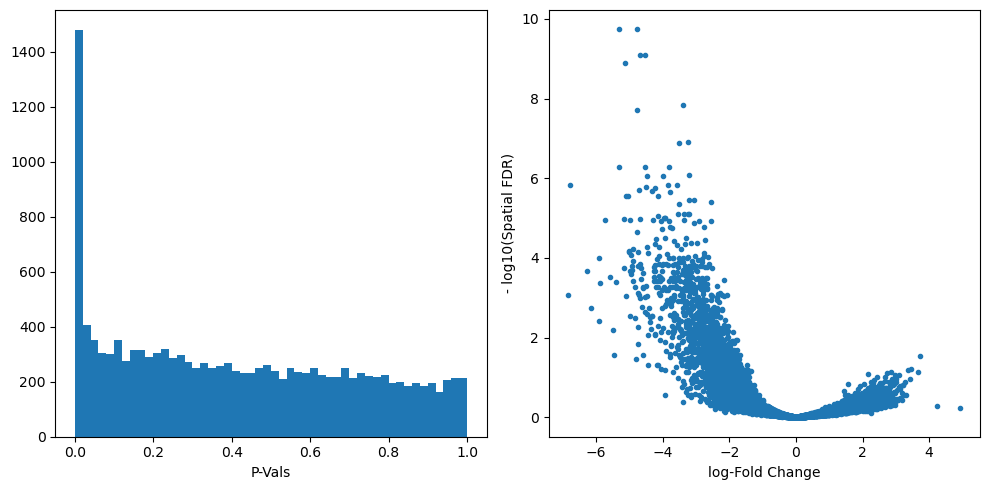

In [38]:
# QC
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_cd8["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_cd8["milo"].var.logFC, -np.log10(mdata_cd8["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

### Visualize embedding

In [79]:
milo.build_nhood_graph(mdata_cd8)

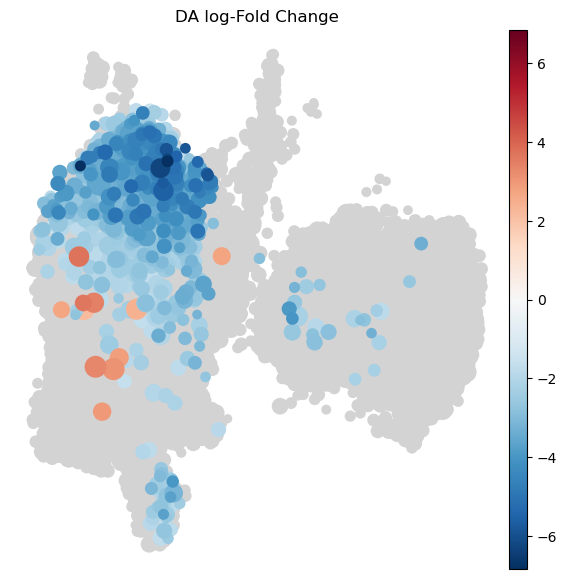

In [80]:
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata_cd8,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot
)

### Visualize by cell type

In [81]:
milo.annotate_nhoods(mdata_cd8, anno_col="pica_cell_type_complete_01_gdT_corrected")


Text(0.5, 0, 'celltype fraction')

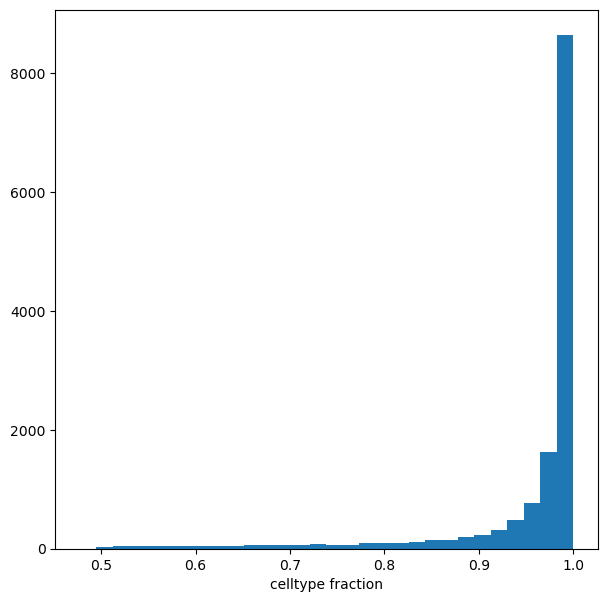

In [82]:
plt.hist(mdata_cd8["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [83]:
mdata_cd8["milo"].var["nhood_annotation"] = mdata_cd8["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata_cd8["milo"].var.loc[mdata_cd8["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pertpy/tools/_milo.py:1014: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nhood_adata.obs[[anno_col, "logFC"]].groupby(anno_col).median().sort_values("logFC", ascending=True).index
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pertpy/tools/_milo.py:1031: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pertpy/tools/_milo.py:1043: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


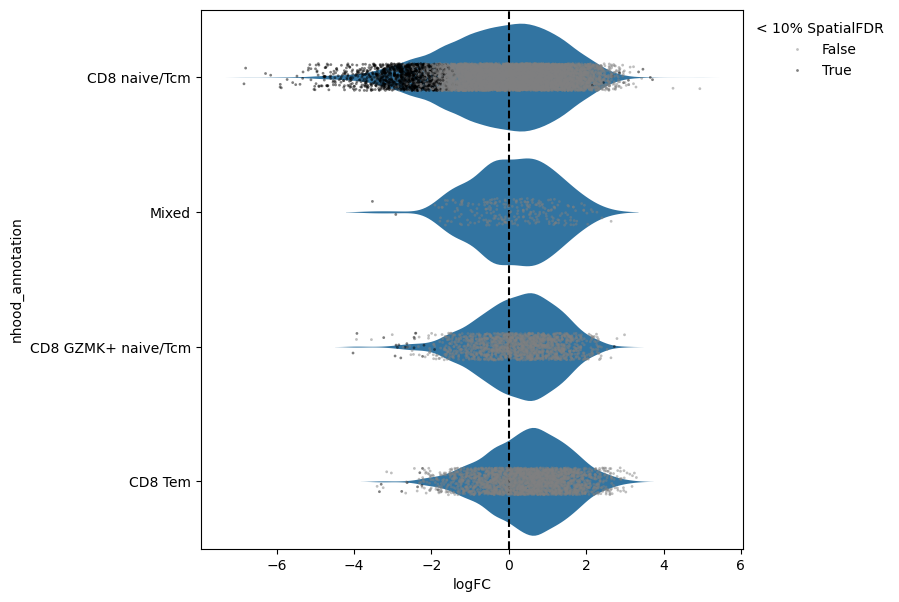

In [84]:
milo.plot_da_beeswarm(mdata_cd8, alpha=0.1)

In [85]:
sig_nhoods_cd8 = mdata_cd8["milo"].var.query(
    "SpatialFDR < 0.1"
).copy()

sig_nhoods_cd8.sort_values("logFC", ascending=False).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac
5163,20250814_WGS_20250814_sc_PICA0147-PICA0173_Poo...,3.104175,5.884402,3.715212,0.001634,0.025872,0.028975,876.0,CD8 naive/Tcm,0.994292
4801,20250814_WGS_20250814_sc_PICA0147-PICA0173_Poo...,3.249149,3.983306,3.658710,0.005737,0.065144,0.072864,582.0,CD8 naive/Tcm,0.994845
7770,20250324_WGS_20250324_sc_PICA0098-PICA0118_Poo...,3.024463,5.497298,3.467906,0.004670,0.056385,0.062961,861.0,CD8 naive/Tcm,0.995354
9539,20250612_WGS_20250612_sc_PICA0119-PICA0146_Poo...,3.009603,6.063617,3.355232,0.004996,0.059033,0.065938,994.0,CD8 naive/Tcm,1.000000
9570,20250612_WGS_20250612_sc_PICA0119-PICA0146_Poo...,3.034744,5.992978,3.093321,0.007502,0.079675,0.088954,1018.0,CD8 naive/Tcm,1.000000


<Figure size 700x700 with 0 Axes>

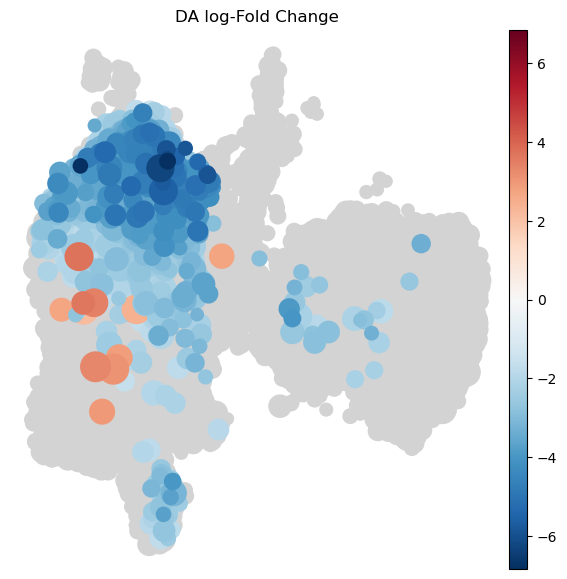

In [86]:
milo.build_nhood_graph(mdata_cd8)

plt.figure(figsize=(7, 7))
milo.plot_nhood_graph(
    mdata_cd8,
    alpha=0.1,        # SpatialFDR threshold
    min_size=2
)

<Axes: xlabel='logFC', ylabel='kth_distance'>

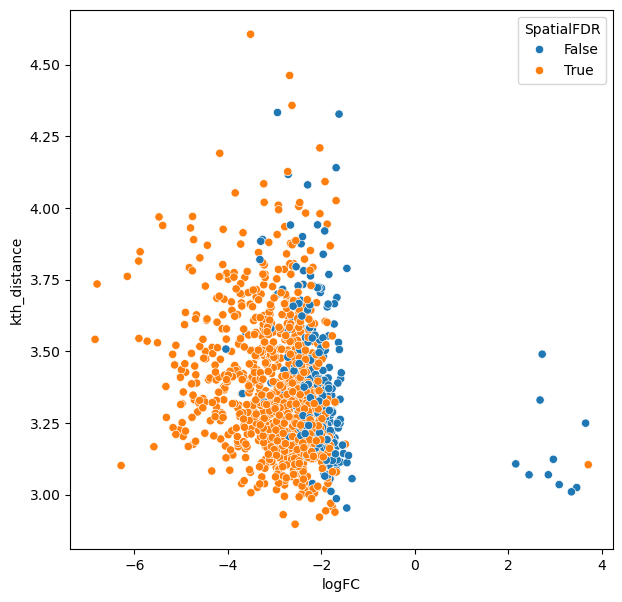

In [87]:
sns.scatterplot(
    data=sig_nhoods_cd8,
    x="logFC",
    y="kth_distance",
    hue=(sig_nhoods_cd8["SpatialFDR"] < 0.05)
)

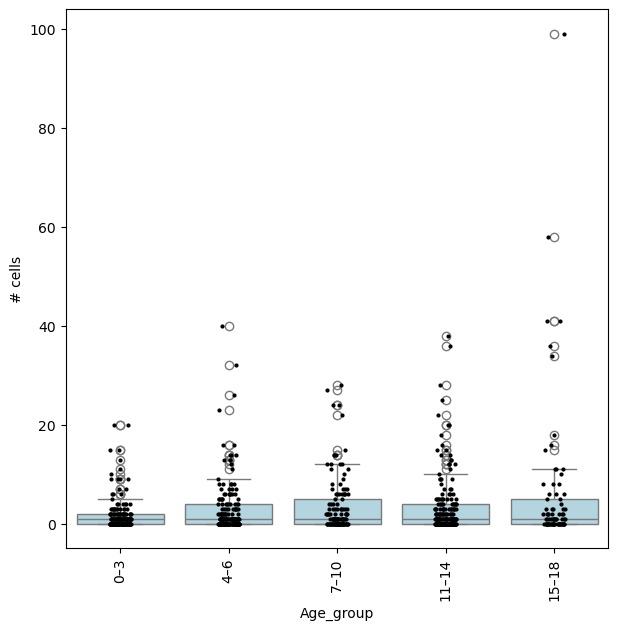

In [88]:
milo.plot_nhood_counts_by_cond(
    mdata_cd8,
    test_var="Age_group",
    subset_nhoods=sig_nhoods_cd8.index[:6],
    log_counts=False
)

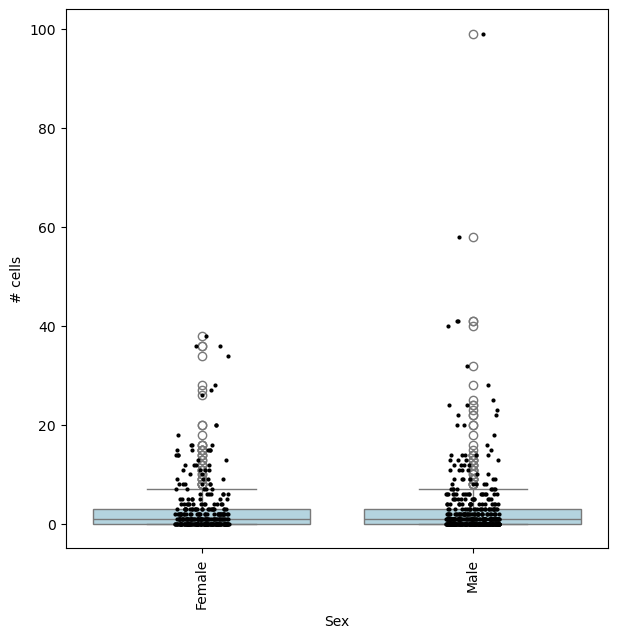

In [89]:
milo.plot_nhood_counts_by_cond(
    mdata_cd8,
    test_var="Sex",
    subset_nhoods=sig_nhoods_cd8.index[:6],
    log_counts=False
)

In [90]:
pl_nhoods_cd8 = (
    mdata_cd8["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=False)
    .index[:6]
)

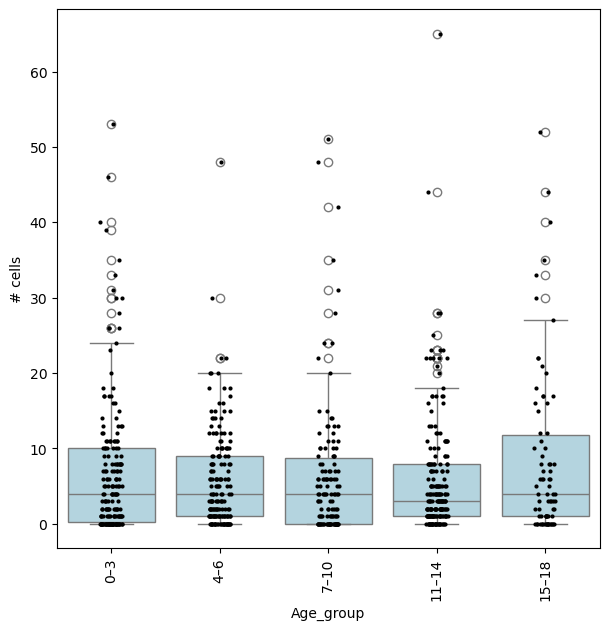

In [91]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_cd8, test_var="Age_group", subset_nhoods=pl_nhoods_cd8, log_counts=False)

In [92]:
pl_nhoods_neg_cd8 = (
    mdata_cd8["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=True)
    .index[:6]
)

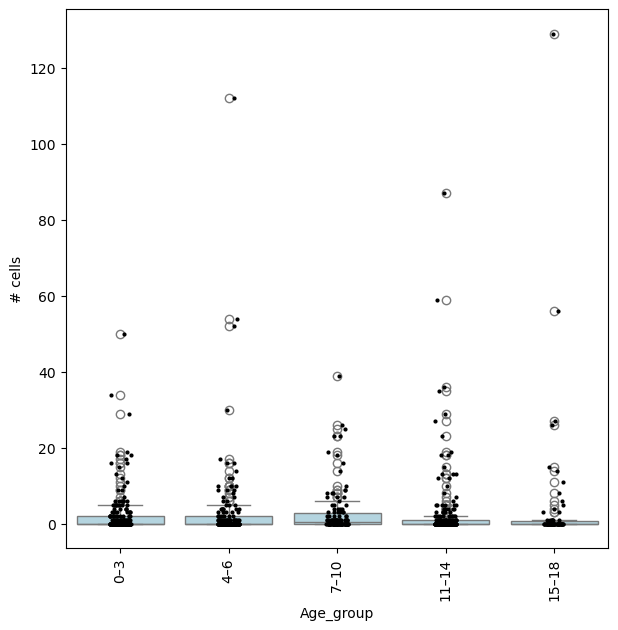

In [93]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_cd8, test_var="Age_group", subset_nhoods=pl_nhoods_neg_cd8, log_counts=False)

In [ ]:
mdata_cd8

MuData object with n_obs × n_vars = 265696 × 52345
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Sex_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'nhood_neighbors_key', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 13739
      obs:	'Age_years', 'Batch', 'Sex', 'pica_id', 'Age', '

: 